Dataset Shape: (768, 7)
Columns in the dataset:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
Cleaned Col

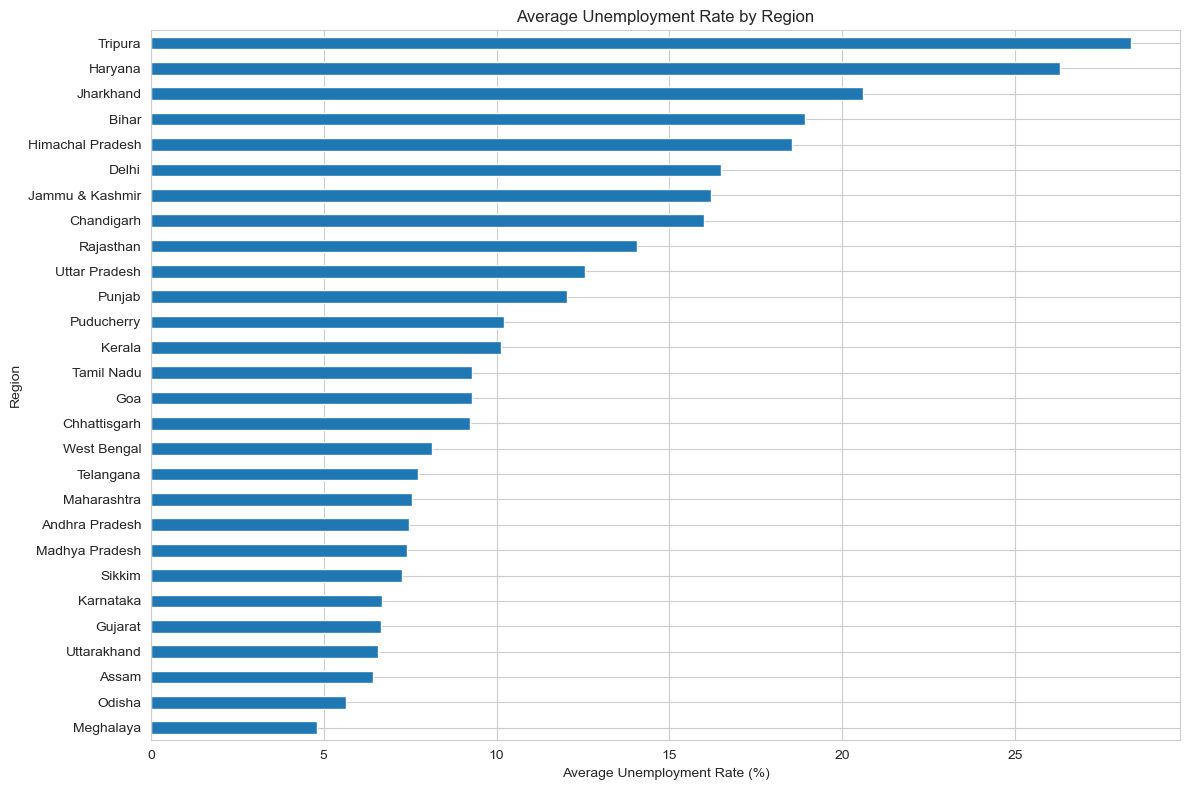

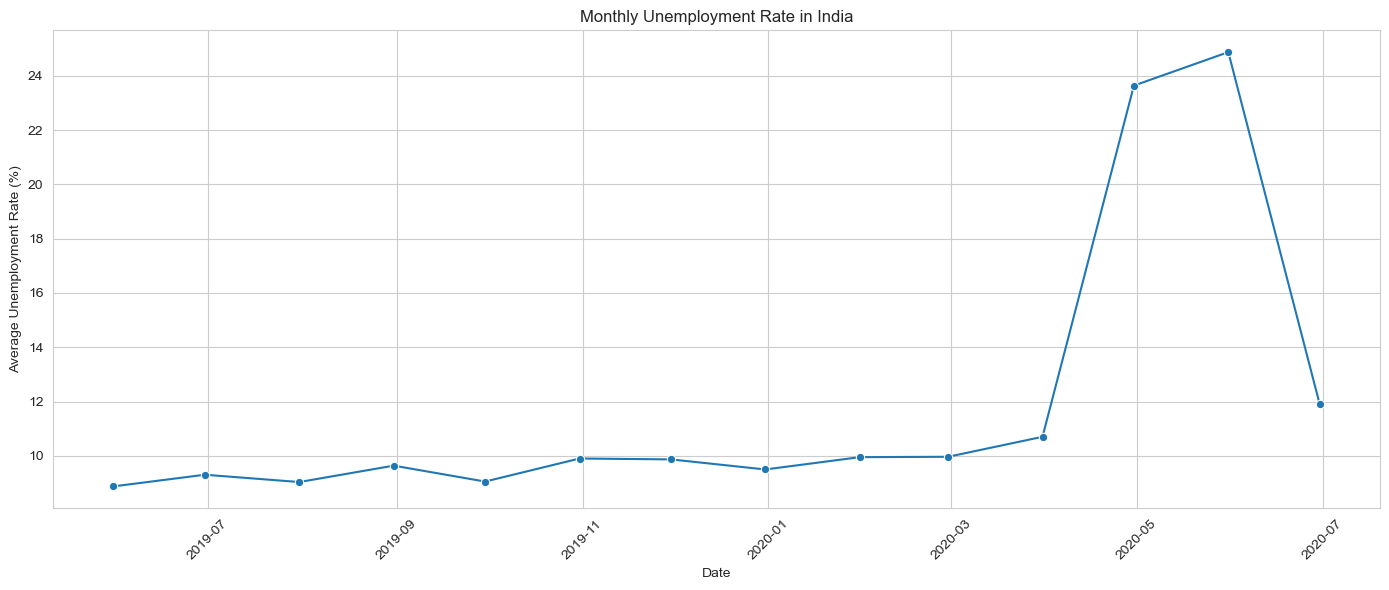

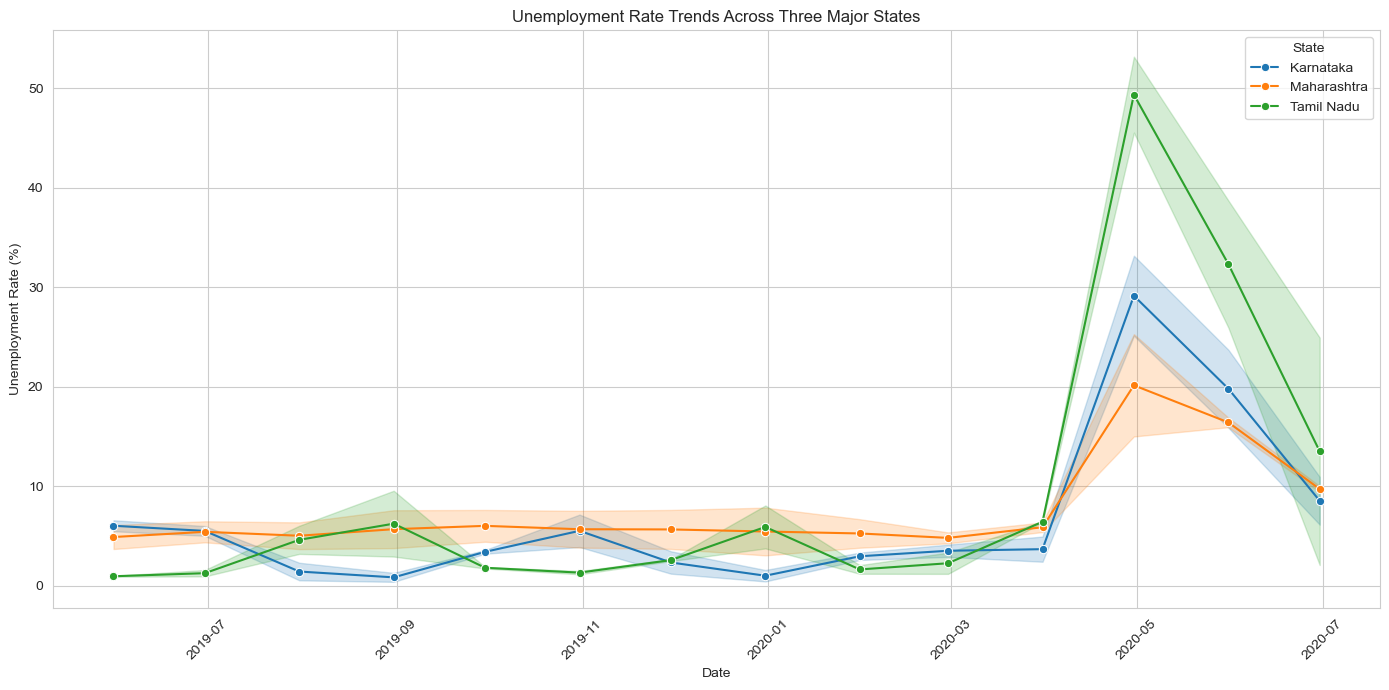

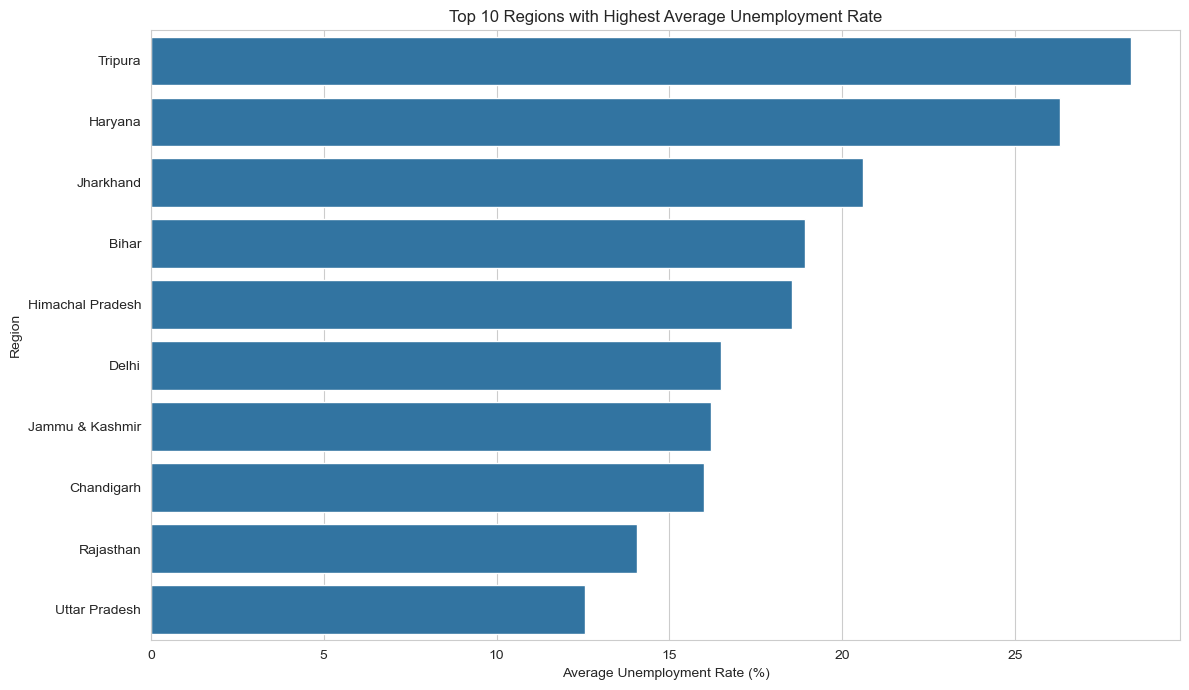

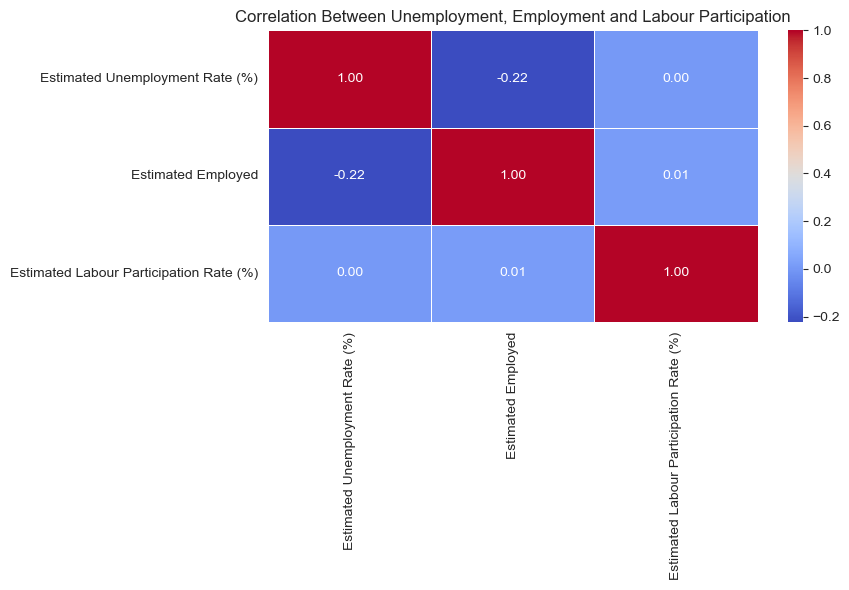

Pre-COVID records: 536
COVID/Lockdown records: 204
Pre-COVID Average Unemployment Rate: 9.51 %
COVID/Lockdown Average Unemployment Rate: 17.77 %
Increase in unemployment rate: 86.91 %


,Period,Unemployment Rate (%),Estimated Employed,Labour Participation Rate (%)
0,Pre-COVID,9.51,7466028.0,43.89
1,COVID/Lockdown,17.77,6517203.0,39.33


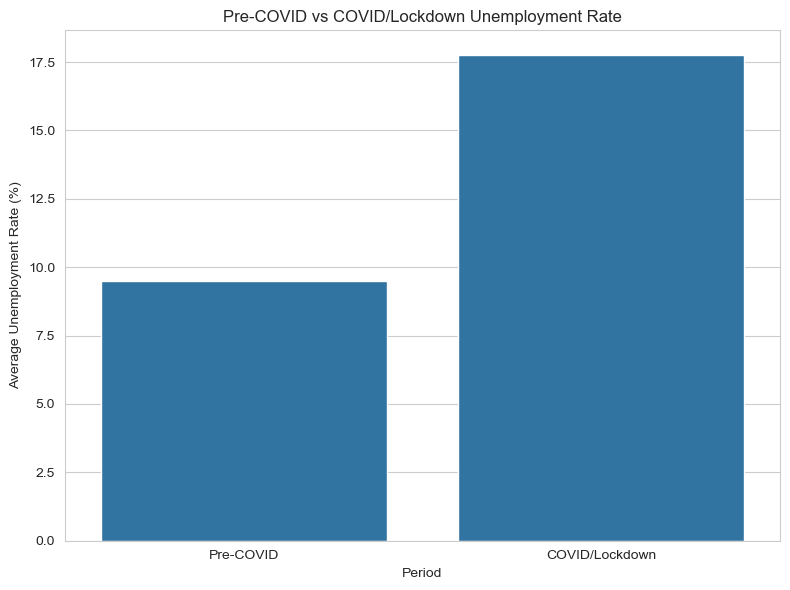

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a clean plotting style
sns.set_style("whitegrid")

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Load the unemployment dataset

df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
df.head()

# Check number of rows and columns

print("Dataset Shape:", df.shape)

# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

# Display data types

df.info()
# Statistical summary of numerical columns

df.describe()

# Remove leading and trailing spaces from column names

df.columns = df.columns.str.strip()

# Display cleaned column names

print("Cleaned Columns:")
print(df.columns.tolist())

# Check unique values in important categorical columns

print("\nNumber of Regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].dropna().unique())

print("\nFrequency values:")
print(df["Frequency"].dropna().unique())

print("\nArea values:")
print(df["Area"].dropna().unique())

# Convert Date column into datetime format

df["Date"] = pd.to_datetime(
    df["Date"].str.strip(),
    dayfirst=True,
    errors="coerce"
)

# Check the date conversion

df[["Date"]].head()

# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Display rows containing missing values

df[df.isnull().any(axis=1)].head(10)


# Remove completely empty rows
df.dropna(how="all", inplace=True)

# Check remaining missing values
print(df.isnull().sum())

# Check shape after removing completely empty rows

print("Shape after removing empty rows:", df.shape)

# Check missing values after cleaning

print(df.isnull().sum())
# Convert numerical columns to numeric data types

numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Check data types after conversion

df.info()

# Final dataset information

print("Final Dataset Shape:", df.shape)

print("\nDate Range:")
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

print("\nNumber of Regions:", df["Region"].nunique())

print("\nMissing Values:")
print(df.isnull().sum())

# Calculate average unemployment rate by region

region_avg_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg_unemployment.head(10)

# Plot average unemployment rate by region

plt.figure(figsize=(12, 8))

region_avg_unemployment.sort_values().plot(
    kind="barh"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# Calculate monthly average unemployment rate

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

monthly_unemployment.head()

# Plot monthly unemployment trend

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Select three major states for comparison

selected_regions = [
    "Maharashtra",
    "Karnataka",
    "Tamil Nadu"
]

state_data = df[df["Region"].isin(selected_regions)]

# Display selected data

state_data.head()

# Plot unemployment trends for three major states

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Trends Across Three Major States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.legend(title="State")

plt.tight_layout()
plt.show()

# Calculate top 10 regions with highest average unemployment rate

top_10_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_unemployment

# Plot top 10 regions

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_unemployment.values,
    y=top_10_unemployment.index
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# Select variables for correlation analysis

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

# Plot correlation heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation"
)

plt.tight_layout()
plt.show()

# Define Pre-COVID and COVID/Lockdown periods

pre_covid = df[df["Date"] < "2020-03-01"]

covid_period = df[df["Date"] >= "2020-03-01"]

print("Pre-COVID records:", len(pre_covid))
print("COVID/Lockdown records:", len(covid_period))

# Calculate average unemployment rate for both periods

pre_covid_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()

covid_avg = covid_period["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average Unemployment Rate:",
      round(pre_covid_avg, 2), "%")

print("COVID/Lockdown Average Unemployment Rate:",
      round(covid_avg, 2), "%")

# Calculate percentage increase in unemployment rate

percentage_change = (
    (covid_avg - pre_covid_avg) / pre_covid_avg
) * 100

print(
    "Increase in unemployment rate:",
    round(percentage_change, 2),
    "%"
)

# Create comparison table

comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "COVID/Lockdown"],
    
    "Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        covid_period["Estimated Unemployment Rate (%)"].mean()
    ],
    
    "Estimated Employed": [
        pre_covid["Estimated Employed"].mean(),
        covid_period["Estimated Employed"].mean()
    ],
    
    "Labour Participation Rate (%)": [
        pre_covid["Estimated Labour Participation Rate (%)"].mean(),
        covid_period["Estimated Labour Participation Rate (%)"].mean()
    ]
})

# Round values for better presentation

comparison["Unemployment Rate (%)"] = comparison["Unemployment Rate (%)"].round(2)

comparison["Estimated Employed"] = comparison["Estimated Employed"].round(0)

comparison["Labour Participation Rate (%)"] = comparison["Labour Participation Rate (%)"].round(2)

# Display comparison table

display(comparison)

# Visual comparison of unemployment rates

plt.figure(figsize=(8, 6))

sns.barplot(
    data=comparison,
    x="Period",
    y="Unemployment Rate (%)"
)

plt.title("Pre-COVID vs COVID/Lockdown Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

